<a href="https://colab.research.google.com/github/huseyinhikmet-wq/Cookie-Cats-A-B-Test/blob/main/Cookie_Cats_AB_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
df=pd.read_csv("cookie_cats.csv")

In [6]:
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,FALSE
1,337,gate_30,38,True,FALSE
2,377,gate_40,165,True,FALSE
3,483,gate_40,1,False,FALSE
4,488,gate_40,179,True,TRUE


In [7]:
df.describe()

,userid,sum_gamerounds
count,3.400900e+04,34009.000000
mean,1.889876e+06,51.229969
std,1.094301e+06,104.099242
min,1.160000e+02,0.000000
25%,9.373760e+05,5.000000
50%,1.893800e+06,16.000000
75%,2.838981e+06,51.000000
max,3.772312e+06,2961.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34009 entries, 0 to 34008
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          34009 non-null  int64 
 1   version         34009 non-null  object
 2   sum_gamerounds  34009 non-null  int64 
 3   retention_1     34009 non-null  bool  
 4   retention_7     34009 non-null  object
dtypes: bool(1), int64(2), object(2)
memory usage: 1.1+ MB


In [9]:
df["version"].value_counts(normalize=True)

,proportion
version,
gate_40,0.501014
gate_30,0.498986


In [10]:
display(df["sum_gamerounds"].describe())

,sum_gamerounds
count,34009.000000
mean,51.229969
std,104.099242
min,0.000000
25%,5.000000
50%,16.000000
75%,51.000000
max,2961.000000


In [11]:

print("--- Oynanan Bölüm İstatistikleri ---")
display(df['sum_gamerounds'].describe())


print("\n--- En Çok Oynayan Kullanıcı ---")
display(df[df['sum_gamerounds'] == df['sum_gamerounds'].max()])

--- Oynanan Bölüm İstatistikleri ---


,sum_gamerounds
count,34009.000000
mean,51.229969
std,104.099242
min,0.000000
25%,5.000000
50%,16.000000
75%,51.000000
max,2961.000000



--- En Çok Oynayan Kullanıcı ---


,userid,version,sum_gamerounds,retention_1,retention_7
7912,871500,gate_30,2961,True,TRUE


In [13]:

yuzdelikler = df['sum_gamerounds'].quantile([0.90, 0.95, 0.99, 0.999])
print("--- Yüzdelik Dilimler (Percentiles) ---")
print(yuzdelikler)

--- Yüzdelik Dilimler (Percentiles) ---
0.900     134.000
0.950     219.000
0.990     493.000
0.999    1062.984
Name: sum_gamerounds, dtype: float64


In [12]:

sinir = df['sum_gamerounds'].quantile(0.99)
print(f"Belirlenen Üst Sınır: {sinir}")


df_clean = df[df['sum_gamerounds'] <= sinir]


print("\n--- Temizlenmiş Veri Özeti ---")
display(df_clean['sum_gamerounds'].describe())

Belirlenen Üst Sınır: 493.0

--- Temizlenmiş Veri Özeti ---


,sum_gamerounds
count,33669.000000
mean,44.273367
std,71.333166
min,0.000000
25%,5.000000
50%,16.000000
75%,49.000000
max,493.000000


In [14]:
df_clean["version"].value_counts(normalize=True)

,proportion
version,
gate_40,0.501589
gate_30,0.498411


In [22]:
df_clean['retention_7'] = df_clean['retention_7'].map({'TRUE': True, 'FALSE': False})
oranlar=df_clean.groupby("version")[["retention_1","retention_7"]].mean()*100
display(oranlar)

/tmp/ipykernel_415/2229267148.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['retention_7'] = df_clean['retention_7'].map({'TRUE': True, 'FALSE': False})


,retention_1,retention_7
version,,
gate_30,44.103450,18.092968
gate_40,44.179299,17.616059


In [19]:
from scipy.stats import mannwhitneyu


group_a = df_clean[df_clean['version'] == 'gate_30']['retention_1']
group_b = df_clean[df_clean['version'] == 'gate_40']['retention_1']


stat, p_value = mannwhitneyu(group_a, group_b)

print(f"Testin p-değeri: {p_value:.4f}")

print("\n--- İSTATİSTİKSEL SONUÇ ---")
if p_value < 0.05:
    print("Fark ŞANS ESERİ DEĞİL. İki grup arasında istatistiksel olarak anlamlı bir fark VAR.")
else:
    print("Fark tamamen ŞANS ESERİ. İki grup arasında matematiksel olarak gerçek bir fark YOK.")

Testin p-değeri: 0.8886

--- İSTATİSTİKSEL SONUÇ ---
Fark tamamen ŞANS ESERİ. İki grup arasında matematiksel olarak gerçek bir fark YOK.


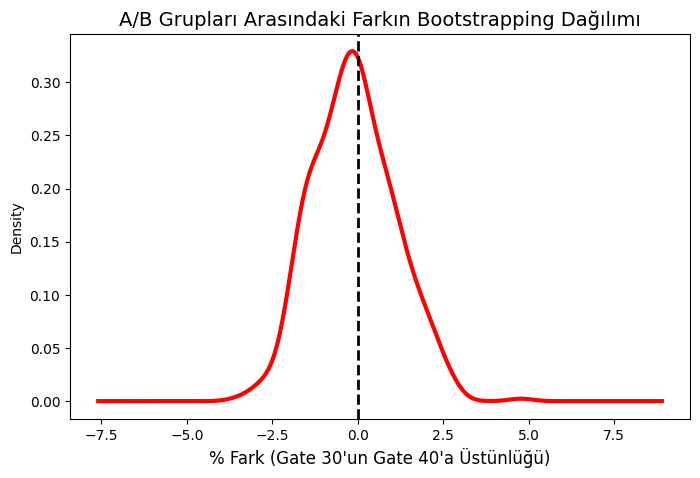

None

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Gün Retention için binlerce kez simülasyon yapıyoruz (Bootstrapping)
boot_1d = []
for i in range(500):
    boot_mean = df_clean.sample(frac=1, replace=True).groupby('version')['retention_1'].mean()
    boot_1d.append(boot_mean)

# Simülasyon sonuçlarını bir tabloya çeviriyoruz
boot_1d = pd.DataFrame(boot_1d)

# İki grup arasındaki YÜZDELİK FARK sütununu oluşturuyoruz
boot_1d['diff'] = (boot_1d['gate_30'] - boot_1d['gate_40']) / boot_1d['gate_40'] * 100

# Grafiği çizdiriyoruz
ax = boot_1d['diff'].plot(kind='kde', figsize=(8,5), color='red', linewidth=3)
ax.set_title("A/B Grupları Arasındaki Farkın Bootstrapping Dağılımı", fontsize=14)
ax.set_xlabel("% Fark (Gate 30'un Gate 40'a Üstünlüğü)", fontsize=12)
ax.axvline(0, color='black', linestyle='--', linewidth=2)
display(plt.show())